# Comparação de modelos: SVM vs. Random Forest

Este notebook compara `LinearSVC`, `SVC` com kernel RBF e `RandomForestClassifier` no dataset próprio de landmarks. A divisão externa usa `session_id` para impedir data leakage entre frames da mesma gravação.

In [23]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC


In [42]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_PATH = PROJECT_ROOT / 'data' / 'jonatas_collected_landmarks.csv'
ANOTHER_DATA = PROJECT_ROOT / 'data' / 'luiz_collected_landmarks.csv'
MODEL_DIR = PROJECT_ROOT / 'model'
MODEL_DIR.mkdir(exist_ok=True)

assert DATASET_PATH.exists(), f'Dataset não encontrado: {DATASET_PATH}'
print(f'Dataset: {DATASET_PATH}')


Dataset: C:\Users\gears\OneDrive\Desktop\DinoGesture\data\jonatas_collected_landmarks.csv


## Dataset e features

As 1.404 features são os 468 landmarks `x`, `y` e `z`, centralizados pelo landmark da ponta do nariz. `session_id` é usado somente para separar as sessões; `frame_index` não entra no modelo.

In [46]:

def process_label(label):
    if label == "boca_aberta":
        return 1
    elif label == "meio_sorriso":
        return 2
    else:
        return 0

In [ ]:
df = pd.read_csv(DATASET_PATH)
df_luiz = pd.read_csv(ANOTHER_DATA)


label
meio_sorriso    1320
boca             840
neutro           720
Name: count, dtype: int64

In [40]:
df = pd.read_csv(DATASET_PATH)
df_luiz = pd.read_csv(ANOTHER_DATA)
df['label'] = df['label'].transform(process_label)
df_luiz['label'] = df_luiz['label'].transform(process_label)

In [ ]:
df.head

,label,session_id,frame_index,x_0,y_0,z_0,x_1,y_1,z_1,x_2,...,z_464,x_465,y_465,z_465,x_466,y_466,z_466,x_467,y_467,z_467
0,0,20260718T010301_167484c8,1,-0.002841,0.069884,0.032910,0.0,0.0,0.0,-0.003070,...,0.079687,0.020105,-0.109469,0.069791,0.095577,-0.122133,0.103731,0.104207,-0.132827,0.105117
1,0,20260718T010301_167484c8,2,-0.002299,0.069744,0.036698,0.0,0.0,0.0,-0.002486,...,0.078699,0.017821,-0.111903,0.068691,0.092355,-0.125688,0.102220,0.100922,-0.135020,0.103425
2,0,20260718T010301_167484c8,3,-0.000818,0.068625,0.035176,0.0,0.0,0.0,-0.001664,...,0.080376,0.019197,-0.111231,0.070196,0.094424,-0.123955,0.103897,0.103064,-0.133130,0.105109
3,0,20260718T010301_167484c8,4,-0.002886,0.067875,0.034778,0.0,0.0,0.0,-0.003114,...,0.080392,0.018073,-0.111257,0.070312,0.092550,-0.124436,0.104615,0.101174,-0.134232,0.105974
4,0,20260718T010301_167484c8,5,-0.001479,0.070155,0.036544,0.0,0.0,0.0,-0.001860,...,0.080196,0.020887,-0.111213,0.069939,0.097508,-0.124087,0.103305,0.106221,-0.133596,0.104479


In [27]:
df = pd.concat([df,df_luiz],axis=0)
len(df)

5640

In [28]:

required_columns = {'label', 'session_id', 'frame_index'}
assert required_columns.issubset(df.columns), 'CSV não possui as colunas de metadados esperadas.'

X = df.drop(columns=['label', 'session_id', 'frame_index'])
y = df['label']
groups = df['session_id']

assert X.shape[1] == 1404, f'Esperadas 1404 features, recebidas {X.shape[1]}.'
print(f'Frames: {len(df):,} | Features: {X.shape[1]} | Labels: {y.nunique()}')
display(df.groupby('label').agg(frames=('label', 'size'), sessoes=('session_id', 'nunique')))


Frames: 5,640 | Features: 1404 | Labels: 3


,frames,sessoes
label,,
0,3240,27
1,1200,10
2,1200,10


## Divisão externa sem data leakage

O teste recebe sessões completas que não participam nem do treinamento nem da busca de hiperparâmetros.

In [29]:
outer_splitter = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
train_index, test_index = next(outer_splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
groups_train, groups_test = groups.iloc[train_index], groups.iloc[test_index]

assert set(groups_train).isdisjoint(groups_test), 'Data leakage: há sessões nos dois conjuntos.'
assert set(y_train) == set(y) == set(y_test), 'Algum label não aparece em treino ou teste.'
print('Labels no treino:', sorted(y_train.unique()))
print('Labels no teste:', sorted(y_test.unique()))
print(f'Sessões no treino: {groups_train.nunique()} | Sessões no teste: {groups_test.nunique()}')
print(f'Features no treino: {X_train.shape[1]} | Features no teste: {X_test.shape[1]}')


Labels no treino: [np.int64(0), np.int64(1), np.int64(2)]
Labels no teste: [np.int64(0), np.int64(1), np.int64(2)]
Sessões no treino: 23 | Sessões no teste: 24
Features no treino: 1404 | Features no teste: 1404


## Grid Search interno

A busca usa apenas o conjunto de treino e também respeita `session_id`. A seleção é feita por F1 macro, dando o mesmo peso a cada expressão.

In [30]:
inner_splitter = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)

searches = {
    'Linear SVC': GridSearchCV(
        estimator=Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LinearSVC(dual='auto', max_iter=10_000, random_state=42)),
        ]),
        param_grid={
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__class_weight': [None, 'balanced'],
        },
        scoring='f1_macro',
        cv=inner_splitter,
        n_jobs=-1,
    ),
    'SVC RBF': GridSearchCV(
        estimator=Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', SVC(kernel='rbf', random_state=42)),
        ]),
        param_grid={
            'classifier__C': [0.1, 1, 10],
            'classifier__gamma': ['scale', 0.001, 0.01],
            'classifier__class_weight': [None, 'balanced'],
        },
        scoring='f1_macro',
        cv=inner_splitter,
        n_jobs=-1,
    ),
    'Random Forest': GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid={
            'n_estimators': [200, 400],
            'max_depth': [None, 20],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 0.5],
        },
        scoring='f1_macro',
        cv=inner_splitter,
        n_jobs=-1,
    ),
}

for name, search in searches.items():
    print(f'\nTreinando {name}...')
    search.fit(X_train, y_train, groups=groups_train)
    print(f'Melhor F1 macro interno: {search.best_score_:.3f}')
    print('Melhores parâmetros:', search.best_params_)



Treinando Linear SVC...
Melhor F1 macro interno: 0.913
Melhores parâmetros: {'classifier__C': 10, 'classifier__class_weight': 'balanced'}

Treinando SVC RBF...
Melhor F1 macro interno: 0.789
Melhores parâmetros: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.001}

Treinando Random Forest...
Melhor F1 macro interno: 0.715
Melhores parâmetros: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 400}


In [31]:
grid_summary = pd.DataFrame([
    {
        'modelo': name,
        'f1_macro_cv': search.best_score_,
        'parametros': search.best_params_,
    }
    for name, search in searches.items()
]).sort_values('f1_macro_cv', ascending=False)
display(grid_summary)


,modelo,f1_macro_cv,parametros
0,Linear SVC,0.913326,"{'classifier__C': 10, 'classifier__class_weigh..."
1,SVC RBF,0.788657,"{'classifier__C': 10, 'classifier__class_weigh..."
2,Random Forest,0.715397,"{'max_depth': None, 'max_features': 0.5, 'min_..."


## Avaliação no teste isolado

Este é o único ponto em que as sessões reservadas são usadas.

In [32]:
labels = sorted(y.unique())
evaluations = {}

for name, search in searches.items():
    y_pred = search.predict(X_test)
    evaluations[name] = {
        'predictions': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, labels=labels, average='macro', zero_division=0),
    }
    print(f'\n## {name}')
    print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

metrics = pd.DataFrame([
    {'modelo': name, 'accuracy': result['accuracy'], 'f1_macro': result['f1_macro']}
    for name, result in evaluations.items()
]).sort_values('f1_macro', ascending=False)
display(metrics)



## Linear SVC
              precision    recall  f1-score   support

           0       0.93      0.86      0.89      1680
           1       0.66      1.00      0.79       600
           2       0.72      0.51      0.59       600

    accuracy                           0.81      2880
   macro avg       0.77      0.79      0.76      2880
weighted avg       0.83      0.81      0.81      2880


## SVC RBF
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      1680
           1       0.95      1.00      0.97       600
           2       0.01      0.01      0.01       600

    accuracy                           0.68      2880
   macro avg       0.55      0.60      0.58      2880
weighted avg       0.60      0.68      0.64      2880


## Random Forest
              precision    recall  f1-score   support

           0       0.71      0.88      0.78      1680
           1       0.88      0.99      0.93       600
           2       0.02      0

,modelo,accuracy,f1_macro
0,Linear SVC,0.813889,0.760476
1,SVC RBF,0.677083,0.575041
2,Random Forest,0.718750,0.575007


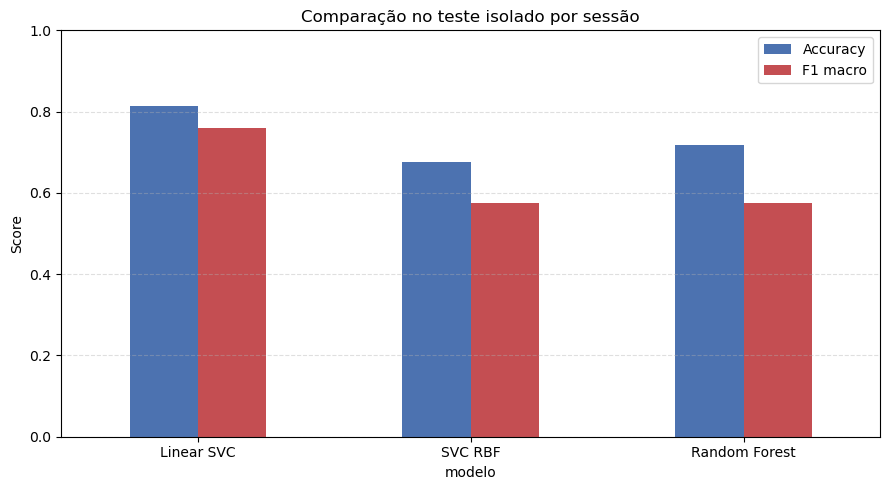

In [33]:
ax = metrics.set_index('modelo')[['accuracy', 'f1_macro']].plot.bar(
    figsize=(9, 5), ylim=(0, 1), rot=0, color=['#4C72B0', '#C44E52']
)
ax.set_title('Comparação no teste isolado por sessão')
ax.set_ylabel('Score')
ax.legend(['Accuracy', 'F1 macro'])
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


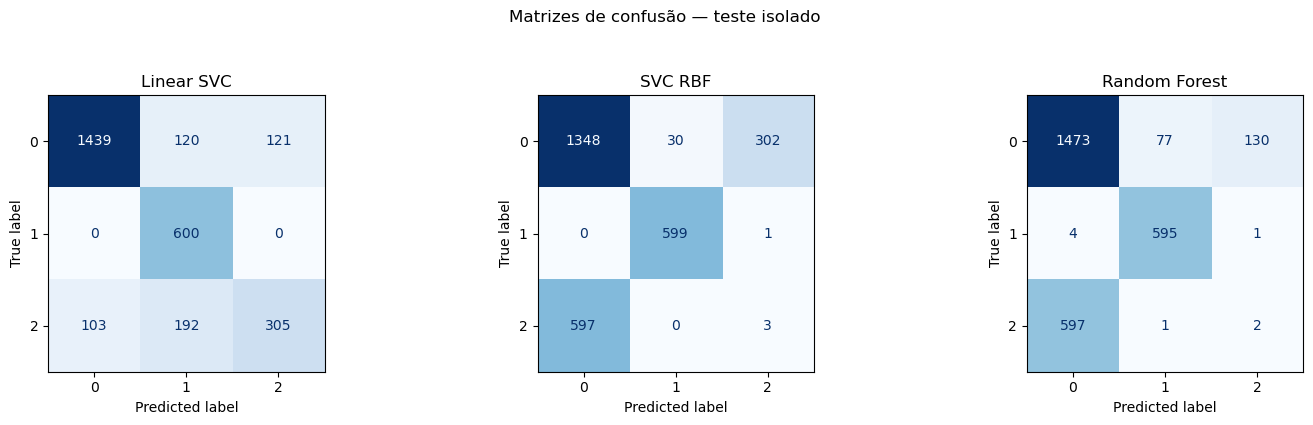

In [34]:
fig, axes = plt.subplots(1, len(evaluations), figsize=(15, 4))
for axis, (name, result) in zip(axes, evaluations.items(), strict=True):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        result['predictions'],
        labels=labels,
        display_labels=labels,
        cmap='Blues',
        colorbar=False,
        ax=axis,
    )
    axis.set_title(name)
fig.suptitle('Matrizes de confusão — teste isolado', y=1.05)
plt.tight_layout()
plt.show()


## Reajuste final e exportação

Depois de registrar as métricas do teste, cada melhor configuração é ajustada novamente com todas as sessões para gerar os artefatos de uso na aplicação.

In [35]:
model_paths = {
    'Linear SVC': MODEL_DIR / 'linear_svc.pkl',
    'SVC RBF': MODEL_DIR / 'rbf_svc.pkl',
    'Random Forest': MODEL_DIR / 'random_forest.pkl',
}

for name, search in searches.items():
    final_model = clone(search.best_estimator_)
    final_model.fit(X, y)
    joblib.dump(final_model, model_paths[name])
    print(f'{name} salvo em {model_paths[name]}')


Linear SVC salvo em C:\Users\gears\OneDrive\Desktop\DinoGesture\model\linear_svc.pkl
SVC RBF salvo em C:\Users\gears\OneDrive\Desktop\DinoGesture\model\rbf_svc.pkl
Random Forest salvo em C:\Users\gears\OneDrive\Desktop\DinoGesture\model\random_forest.pkl


In [36]:
for name, model_path in model_paths.items():
    loaded_model = joblib.load(model_path)
    prediction = loaded_model.predict(X.iloc[[0]])[0]
    print(f'{name}: recarregado e previsto {prediction} com 1404 features.')


Linear SVC: recarregado e previsto 0 com 1404 features.
SVC RBF: recarregado e previsto 0 com 1404 features.
Random Forest: recarregado e previsto 0 com 1404 features.
